Trace length: 24996047 samples


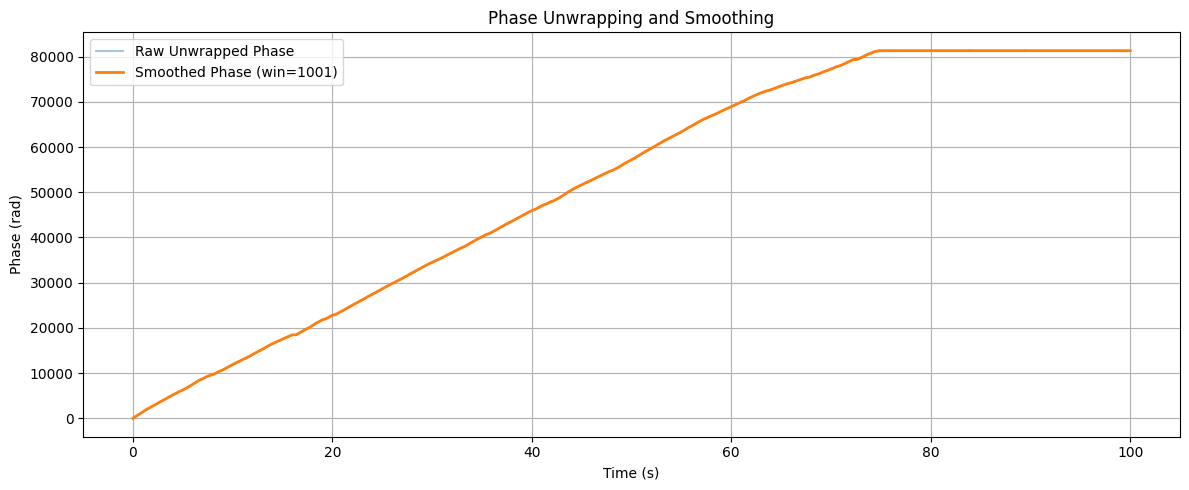

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# === Parameters ===
npz_path = "results_checked/2025.04.15 patricia/file/phase_data.npz"  # ⬅️ Change this
smoothing_window = 1001             # Must be odd
polyorder = 2

# === Load data
data = np.load(npz_path)
phase0 = data["phase0"]             # Index from 0 to 199
timestamps = data["phase_time"]

print(f"Trace length: {len(phase0)} samples")

# === Convert to phase in radians
phase_raw = (phase0 / 200) * 2 * np.pi
phase_unwrapped = np.unwrap(phase_raw)

# === Apply Savitzky-Golay smoothing
phase_smooth = savgol_filter(phase_unwrapped, window_length=smoothing_window, polyorder=polyorder)

# === Plot
plt.figure(figsize=(12, 5))
plt.plot(timestamps, phase_unwrapped, label="Raw Unwrapped Phase", alpha=0.4)
plt.plot(timestamps, phase_smooth, label=f"Smoothed Phase (win={smoothing_window})", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Phase (rad)")
plt.title("Phase Unwrapping and Smoothing")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


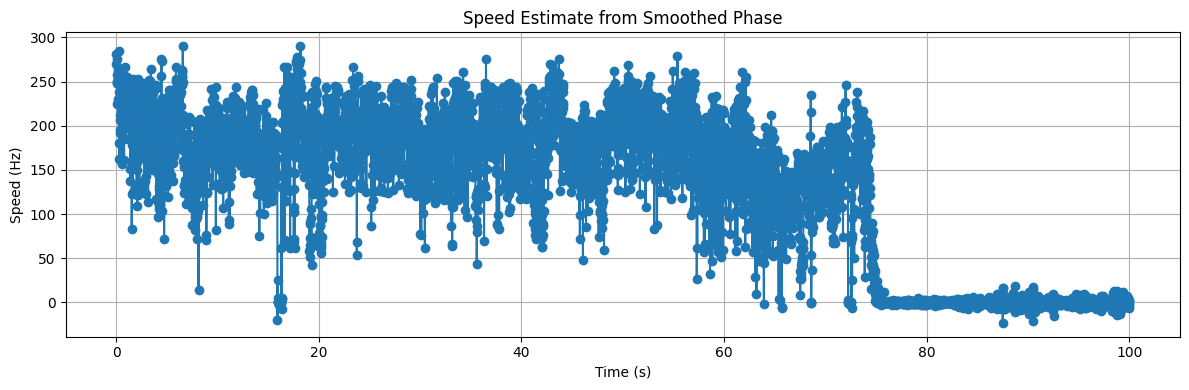

✅ Saved speed trace to: results_checked/2025.04.15 patricia/file\smoothed_speed_trace.csv


In [2]:
import os
import pandas as pd

# === Parameters for speed estimation ===
window_size = 4000  # samples per speed window
output_dir = os.path.dirname(npz_path)
output_csv = os.path.join(output_dir, "smoothed_speed_trace.csv")

# === Compute speed
speeds = []
t_centers = []

for i in range(0, len(phase_smooth) - window_size + 1, window_size):
    start = i
    end = i + window_size

    dphi = phase_smooth[end - 1] - phase_smooth[start]
    dt = timestamps[end - 1] - timestamps[start]
    hz = dphi / (2 * np.pi * dt)

    t_center = 0.5 * (timestamps[start] + timestamps[end - 1])
    speeds.append(hz)
    t_centers.append(t_center)

# === Plot speed
plt.figure(figsize=(12, 4))
plt.plot(t_centers, speeds, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Speed (Hz)")
plt.title("Speed Estimate from Smoothed Phase")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Save to CSV
df_speed = pd.DataFrame({
    "Time (s)": t_centers,
    "Speed (Hz)": speeds
})
df_speed.to_csv(output_csv, index=False)
print(f"✅ Saved speed trace to: {output_csv}")
